# Macaulay DCF Equity Duration (EURO500)

Dieses Notebook berechnet die Macaulay DCF Equity Duration nach deiner Definition mit:
- Zielhorizont: `T = 5` (wo moeglich, sonst kuerzer je Zeile)
- Diskontsatz: `r = 10%`
- LTG-Umrechnung: `LTGMean` in Prozentpunkten -> Dezimal (`/100`)
- Terminalstruktur: Two-Stage (Fade auf `g_infinity = 2%`, danach Ewigkeit)

Cashflows werden als `C_{i,s}` aus verfuegbaren Forward-Forecasts interpretiert.


## Definition: EQ Duration (Macaulay DCF) im Notebook

Dieses Notebook berechnet pro Firma \(i\) und As-of-Datum die **Macaulay DCF Equity Duration** mit Zielhorizont:

- Forecast-Horizont: \(T = 5\)
- Diskontsatz: \(r = 0.1\)
- LTG-Umrechnung: \(LTG_{it}^{dec} = LTGMean_{it}/100\)
- Firmenwachstum (kurzfristig): \(g_{it} = \min(LTG_{it}^{dec}, 0.05)\)
- Long-run Wachstum: \(g_{\infty}=0.02\)
- Terminalstruktur: **Two-Stage** mit linearem Fade ueber `FADE_YEARS=10` von \(g_{it}\) auf \(g_{\infty}\), danach Perpetuity.

### Row-wise Regel "T=5 wo moeglich"

- Pro Zeile wird \(H_i\) als Zahl verfuegbarer Forecasts bis max. 5 gesetzt.
- Wenn FY1..FY5 vorhanden: \(H_i=5\).
- Wenn spaetere Forecasts fehlen: \(H_i<5\), Berechnung nutzt den laengsten verfuegbaren Horizont.
- Mindestbedingung: \(H_i \ge 3\), sonst `status = invalid`.

### 1) Barwerte

\[
PV_i^F = \sum_{s=1}^{H_i} \frac{C_{i,s}}{(1+r)^s}
\]

**Stage A (Fade):** fuer \(k=1,\dots,N\) mit \(N=10\)
\[
g_{i,k} = g_i + \frac{k}{N}(g_{\infty}-g_i), \qquad C_{i,H_i+k}=C_{i,H_i+k-1}(1+g_{i,k})
\]

**Stage B (Perpetuity ab \(H_i+N+1\)):**
\[
TV_{i,perp}(H_i+N)=\frac{C_{i,H_i+N}(1+g_{\infty})}{r-g_{\infty}}
\]

Gesamt:
\[
PV_i^{TV}=PV_i^{fade}+PV_i^{perp}, \qquad P_i^{DCF}=PV_i^F+PV_i^{TV}
\]

### 2) Macaulay Duration

Die Duration wird als gewichteter Zeitpunkt aller abgezinsten Forecast- und Terminal-CFs berechnet (Stage-A-CFs plus Stage-B-Perpetuityblock).

Zusatzmetrik:
\[\text{TerminalWeight}_i = \frac{PV_i^{TV}}{P_i^{DCF}}\]

Im Code entsprechen zentrale Spalten: `PV_F`, `PV_TV_fade`, `PV_TV_perp`, `PV_TV`, `P_DCF`, `Duration_num`, `Duration_DCF_Macaulay`, `Terminal_weight`, `LTGMean_dec`, `g_used`, `H_used`.

### 3) Gueltigkeitsregel (`status`)

- `status = 'ok'`, falls `P_DCF > 0`, `H_used >= 3`, `g_used < r` und nicht fehlend.
- sonst `status = 'invalid_P_DCF_nonpositive_or_missing'`.

### 4) Gespeicherter Output

Ergebnisdatei: `Project_Data/intermediate/EQDuration_Macaulay.parquet`


In [47]:
from pathlib import Path
import numpy as np
import pandas as pd

BASE_DIR = Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data')
DATA_DIR = BASE_DIR / 'intermediate'

R = 0.1
T = 5
G_CAP = 0.05   # row-wise cap: g_it = min(LTG_it_dec, 5%)
G_INF = 0.02   # long-run growth after fade
FADE_YEARS = 10

if R <= max(G_CAP, G_INF):
    raise ValueError(f'Need r > max(g_cap, g_inf). Got r={R}, g_cap={G_CAP}, g_inf={G_INF}')

print('Data dir:', DATA_DIR)
print('Parameters:', {'T': T, 'r': R, 'g_cap': G_CAP, 'g_inf': G_INF, 'fade_years': FADE_YEARS})


Data dir: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate
Parameters: {'T': 5, 'r': 0.1, 'g_cap': 0.05, 'g_inf': 0.02, 'fade_years': 10}


In [48]:
# 1) Tabelle laden: primär EURO500_NPS, sonst Fallback
candidate_files = [
    'euro500_x_EPS.parquet',
]

selected_path = None
for name in candidate_files:
    p = DATA_DIR / name
    if p.exists():
        selected_path = p
        break

if selected_path is None:
    raise FileNotFoundError('Keine passende Input-Tabelle gefunden (EURO500_NPS/EURO500_EPS/cfps_forecasts).')

df = pd.read_parquet(selected_path).copy()
print('Loaded:', selected_path)
print('Shape:', df.shape)
print('Columns (first 30):', list(df.columns)[:30])


Loaded: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_x_EPS.parquet
Shape: (54000, 30)
Columns (first 30): ['date', 'formation_date', 'effective_date', 'quarter', 'RIC', 'name', 'hq_country', 'hq_code', 'trbc_sector_code', 'trbc_sector', 'mcap_eur', 'RIC_snapshot', 'RIC_current', 'ISIN', 'SEDOL', 'FreeFloat', 'FreeFloatPct', 'Volume', 'PriceClose', 'InstrumentType', 'firm_id', 'rank_mcap', 'asof_date', 'pull_ric', 'EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5', 'LTGMean']


In [49]:
# 2) Cashflow-Spalten robust erkennen (T=5 wo moeglich)
cashflow_priority = [
    ['NPS_FY1', 'NPS_FY2', 'NPS_FY3', 'NPS_FY4', 'NPS_FY5'],
    ['EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5'],
    ['FY1', 'FY2', 'FY3', 'FY4', 'FY5'],
]

cf_cols = None
for cand in cashflow_priority:
    available = [c for c in cand if c in df.columns]
    if len(available) >= 3:
        cf_cols = available[:T]  # capped at target horizon
        break

if cf_cols is None:
    raise KeyError('No suitable cashflow columns found. Need at least FY1..FY3.')

print('Using cashflow columns:', cf_cols)

id_candidates = ['RIC', 'firm_id', 'name', 'date', 'asof_date', 'quarter', 'year']
id_cols = [c for c in id_candidates if c in df.columns]
print('ID columns used:', id_cols)


Using cashflow columns: ['EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5']
ID columns used: ['RIC', 'firm_id', 'name', 'date', 'asof_date', 'quarter']


In [50]:
# 3) Macaulay DCF Equity Duration berechnen (T=5 wo moeglich, Two-Stage terminal)
work = df.copy()
for ccol in cf_cols:
    work[ccol] = pd.to_numeric(work[ccol], errors='coerce').astype('float64')

# row-wise growth rate: LTGMean in percentage points -> decimal, then cap
if 'LTGMean' not in work.columns:
    raise KeyError('LTGMean column missing in input. Please run LTG pull first.')
work['LTGMean'] = pd.to_numeric(work['LTGMean'], errors='coerce').astype('float64')
work['LTGMean_dec'] = work['LTGMean'] / 100.0
work['g_used'] = np.minimum(work['LTGMean_dec'], G_CAP)

# number of available forward CFs per row (up to T)
work['H_used'] = work[cf_cols].notna().sum(axis=1).astype(int)
work.loc[work['H_used'] > T, 'H_used'] = T

# PV of explicit forecast period and duration numerator part
work['PV_F'] = 0.0
work['Duration_num_F'] = 0.0
for s, ccol in enumerate(cf_cols, start=1):
    disc = (1 + R) ** s
    cf = work[ccol]
    add = cf / disc
    work['PV_F'] += add.fillna(0.0)
    work['Duration_num_F'] += s * add.fillna(0.0)

# terminal cashflow anchor = last available CF in row (up to horizon H_used)
last_cf = pd.Series(np.nan, index=work.index, dtype='float64')
for s, ccol in enumerate(cf_cols, start=1):
    mask = work['H_used'].eq(s)
    last_cf.loc[mask] = work.loc[mask, ccol]

# ----- Two-Stage Terminal -----
# Stage A: fade from g_used to g_inf over FADE_YEARS
# Stage B: perpetuity with g_inf starting after fade

pv_stageA_t0 = pd.Series(0.0, index=work.index, dtype='float64')
num_stageA_t0 = pd.Series(0.0, index=work.index, dtype='float64')

cf_prev = last_cf.copy()
cf_N = pd.Series(np.nan, index=work.index, dtype='float64')

for k in range(1, FADE_YEARS + 1):
    w = k / FADE_YEARS
    gk = work['g_used'] + (G_INF - work['g_used']) * w
    cf_k = cf_prev * (1 + gk)

    # discount from (H + k) to t0, done by H-buckets
    pv_k = pd.Series(np.nan, index=work.index, dtype='float64')
    for h in sorted(work['H_used'].dropna().unique()):
        if h <= 0:
            continue
        mask = work['H_used'].eq(int(h))
        pv_k.loc[mask] = cf_k.loc[mask] / ((1 + R) ** (int(h) + k))

    pv_stageA_t0 += pv_k.fillna(0.0)

    # Macaulay numerator contribution (time weight = H + k)
    for h in sorted(work['H_used'].dropna().unique()):
        if h <= 0:
            continue
        mask = work['H_used'].eq(int(h))
        num_stageA_t0.loc[mask] += (int(h) + k) * pv_k.loc[mask].fillna(0.0)

    cf_prev = cf_k
    cf_N = cf_k

# Stage B perpetuity (from H+N+1 onward with g_inf)
tv_perp_at_HN = cf_N * (1 + G_INF) / (R - G_INF)
pv_perp_t0 = pd.Series(np.nan, index=work.index, dtype='float64')
num_perp_t0 = pd.Series(np.nan, index=work.index, dtype='float64')

for h in sorted(work['H_used'].dropna().unique()):
    if h <= 0:
        continue
    mask = work['H_used'].eq(int(h))
    pv_perp_t0.loc[mask] = tv_perp_at_HN.loc[mask] / ((1 + R) ** (int(h) + FADE_YEARS))
    # time shift for perpetuity block
    term = int(h) + FADE_YEARS + (1 + R) / (R - G_INF)
    num_perp_t0.loc[mask] = term * pv_perp_t0.loc[mask]

work['PV_TV_fade'] = pv_stageA_t0
work['PV_TV_perp'] = pv_perp_t0
work['PV_TV'] = work['PV_TV_fade'] + work['PV_TV_perp']
work['P_DCF'] = work['PV_F'] + work['PV_TV']

work['Duration_num_TV'] = num_stageA_t0 + num_perp_t0
work['Duration_num'] = work['Duration_num_F'] + work['Duration_num_TV']

# terminal weight
work['Terminal_weight'] = np.where(
    work['P_DCF'].notna() & (work['P_DCF'] != 0),
    work['PV_TV'] / work['P_DCF'],
    np.nan,
)

valid = (
    work['P_DCF'].notna()
    & (work['P_DCF'] > 0)
    & (work['H_used'] >= 3)
    & work['g_used'].notna()
    & (work['g_used'] < R)
)
work['Duration_DCF_Macaulay'] = np.nan
work.loc[valid, 'Duration_DCF_Macaulay'] = (
    work.loc[valid, 'Duration_num'] / work.loc[valid, 'P_DCF']
)
work['status'] = np.where(valid, 'ok', 'invalid_P_DCF_nonpositive_or_missing')

res_cols = id_cols + cf_cols + [
    'LTGMean', 'LTGMean_dec', 'g_used', 'H_used',
    'PV_F', 'PV_TV_fade', 'PV_TV_perp', 'PV_TV', 'P_DCF', 'Terminal_weight',
    'Duration_num', 'Duration_DCF_Macaulay', 'status'
]
result = work[res_cols].copy()

print(result['status'].value_counts(dropna=False))
print('Valid share:', float((result['status'] == 'ok').mean()))
print('H_used distribution:')
print(result['H_used'].value_counts(dropna=False).sort_index())
print('g_used describe (ok rows):')
print(result.loc[result['status'].eq('ok'), 'g_used'].describe())
print('Terminal_weight describe (ok rows):')
print(result.loc[result['status'].eq('ok'), 'Terminal_weight'].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]))
result.head(10)


status
ok                                      29841
invalid_P_DCF_nonpositive_or_missing    24159
Name: count, dtype: int64
Valid share: 0.5526111111111112
H_used distribution:
H_used
0     6434
1      395
2     2099
3    14185
4    11258
5    19629
Name: count, dtype: int64
g_used describe (ok rows):
count    29841.000000
mean         0.033615
std          0.056883
min         -1.855200
25%          0.050000
50%          0.050000
75%          0.050000
max          0.050000
Name: g_used, dtype: float64
Terminal_weight describe (ok rows):
count    29841.000000
mean         0.773516
std          1.960843
min         -4.851750
1%           0.519685
5%           0.658658
50%          0.757966
95%          0.841843
99%          0.901445
max        337.286487
Name: Terminal_weight, dtype: float64


,RIC,firm_id,name,date,asof_date,quarter,EPS_FY1,EPS_FY2,EPS_FY3,EPS_FY4,...,H_used,PV_F,PV_TV_fade,PV_TV_perp,PV_TV,P_DCF,Terminal_weight,Duration_num,Duration_DCF_Macaulay,status
0,FTE.PA,FIRM0001344,Orange SA,1998-12-31,1998-12-31,1999Q1,1.82531,2.05258,2.32465,2.57205,...,4,6.859009,12.980932,12.001785,24.982718,31.841726,0.784591,466.959773,14.665027,ok
1,OLIV.MI,FIRM0001885,Telecom Italia SpA,1998-12-31,1998-12-31,1999Q1,-0.02329,0.01357,0.03909,0.07045,...,4,0.067529,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,invalid_P_DCF_nonpositive_or_missing
2,NOKIA.HE,FIRM0000965,Nokia Oyj,1998-12-31,1998-12-31,1999Q1,0.32845,0.38263,0.44510,NaN,...,3,0.949224,2.471023,2.284634,4.755657,5.704882,0.833612,82.771339,14.508862,ok
3,ENI.MI,FIRM0001944,Eni SpA,1998-12-31,1998-12-31,1999Q1,0.62751,0.66909,0.75986,0.85716,...,5,2.824784,4.027167,3.723400,7.750567,10.575351,0.732890,155.701862,14.723092,ok
4,DCXGn.DE,FIRM0000456,Mercedes-Benz Group AG,1998-12-31,1998-12-31,1999Q1,4.93516,6.28406,6.89331,8.86788,...,5,26.694230,42.697408,39.476758,82.174165,108.868396,0.754803,1644.681674,15.107063,ok
5,OREP.PA,FIRM0001301,L'Oreal SA,1998-12-31,1998-12-31,1999Q1,1.05780,1.18829,1.36275,NaN,...,3,2.967548,7.565460,6.994800,14.560261,17.527809,0.830695,253.493874,14.462382,ok
6,TEF.MC,FIRM0000947,Telefonica SA,1998-12-31,1998-12-31,1999Q1,0.29697,0.34545,0.40760,0.46552,...,4,1.179661,2.349443,2.172225,4.521667,5.701328,0.793090,84.412856,14.805823,ok
7,TYC.N,FIRM0000167,Johnson Controls International PLC,1998-12-31,1998-12-31,1999Q1,5.81437,7.28796,NaN,NaN,...,2,11.308898,44.505925,41.148859,85.654784,96.963682,0.883370,1387.644586,NaN,invalid_P_DCF_nonpositive_or_missing
8,EAUG.PA,FIRM0001332,Vivendi SE,1998-12-31,1998-12-31,1999Q1,2.02372,2.52568,2.88242,3.25611,...,4,8.316656,16.433329,15.193769,31.627098,39.943754,0.791791,590.634324,14.786650,ok
9,MDT.N,FIRM0001853,Medtronic PLC,1998-12-31,1998-12-31,1999Q1,0.76278,0.92591,1.07500,NaN,...,3,2.266315,5.967984,5.517821,11.485805,13.752119,0.835203,199.883548,14.534745,ok


In [51]:
# 4) Plausibilitätscheck (nur gültige Zeilen)
ok = result[result['status'] == 'ok'].copy()
if len(ok) == 0:
    print('No valid rows found.')
else:
    print(ok['Duration_DCF_Macaulay'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
    if 'year' in ok.columns:
        print('Rows per year (head):')
        print(ok.groupby('year').size().head(10))


count    29841.000000
mean        14.686371
std         32.713527
min        -78.156787
1%           9.858527
5%          12.726867
50%         14.577010
95%         15.565427
99%         16.817111
max       5626.612496
Name: Duration_DCF_Macaulay, dtype: float64


In [52]:
# 5) Speichern
out_path = DATA_DIR / 'EQDuration_Macaulay.parquet'
result.to_parquet(out_path, index=False)
print('Saved:', out_path)


Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Macaulay.parquet


## 6) Analyse: Datenqualität und Verteilung

Diese Sektion prüft, wie belastbar das Duration-Maß ist (Validität, Ausreißer, Verteilung).


,metric,value
0,rows_total,54000.000000
1,rows_ok,29841.000000
2,rows_invalid,24159.000000
3,ok_share,0.552611
4,share_missing_any_CF,0.636500
5,share_nonpositive_P_DCF,0.001759


Duration describe (ok only):


count    29841.000000
mean        14.686371
std         32.713527
min        -78.156787
1%           9.858527
5%          12.726867
25%         14.286844
50%         14.577010
75%         14.896782
95%         15.565427
99%         16.817111
max       5626.612496
Name: Duration_DCF_Macaulay, dtype: float64

Winsorized 1%-99% describe (ok only):


count    29841.000000
mean        14.456420
std          0.954422
min          9.858527
1%           9.859263
5%          12.726867
25%         14.286844
50%         14.577010
75%         14.896782
95%         15.565427
99%         16.814923
max         16.817111
Name: Duration_DCF_Macaulay, dtype: float64

Terminal_weight describe (ok only):


count    29841.000000
mean         0.773516
std          1.960843
min         -4.851750
1%           0.519685
5%           0.658658
25%          0.729117
50%          0.757966
75%          0.803693
95%          0.841843
99%          0.901445
max        337.286487
Name: Terminal_weight, dtype: float64

Terminal_weight winsorized 1%-99% describe:


count    29841.000000
mean         0.759737
std          0.061454
min          0.519685
1%           0.519827
5%           0.658658
25%          0.729117
50%          0.757966
75%          0.803693
95%          0.841843
99%          0.901420
max          0.901445
Name: Terminal_weight, dtype: float64

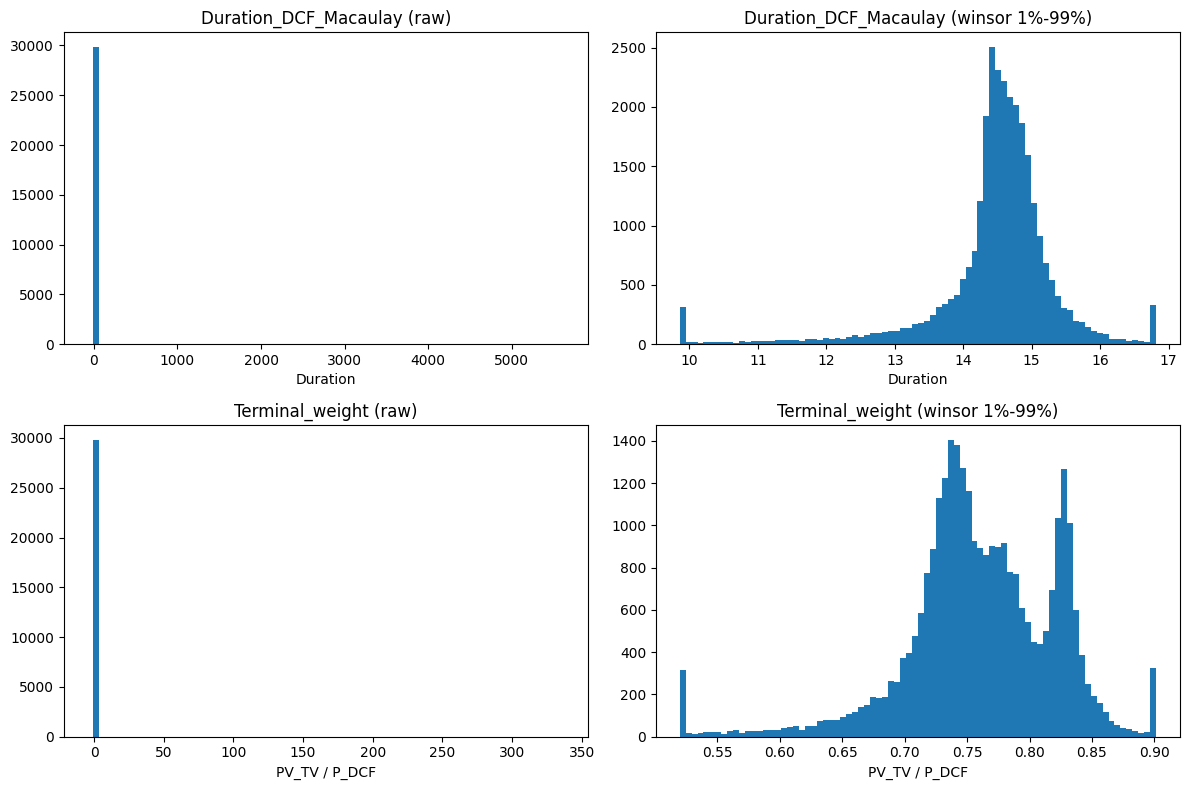

Cross-sectional std per quarter:


count    108.000000
mean       4.599072
std       29.968952
min        0.459811
25%        0.883386
50%        1.191725
75%        1.604698
max      311.778143
Name: Duration_DCF_Macaulay, dtype: float64

In [53]:
import matplotlib.pyplot as plt
ana = result.copy()
ana['is_ok'] = ana['status'].eq('ok')
n_total = len(ana)
n_ok = int(ana['is_ok'].sum())
n_bad = n_total - n_ok
cf_missing = ana[cf_cols].isna().any(axis=1)
pdcf_nonpos = ana['P_DCF'].notna() & (ana['P_DCF'] <= 0)
quality = pd.DataFrame({
    'metric': [
        'rows_total',
        'rows_ok',
        'rows_invalid',
        'ok_share',
        'share_missing_any_CF',
        'share_nonpositive_P_DCF'
    ],
    'value': [
        n_total,
        n_ok,
        n_bad,
        n_ok / n_total if n_total else np.nan,
        float(cf_missing.mean()),
        float(pdcf_nonpos.mean())
    ]
})
display(quality)

d_ok = ana.loc[ana['is_ok'], 'Duration_DCF_Macaulay'].dropna()
print('Duration describe (ok only):')
display(d_ok.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

d_w = d_ok.clip(lower=d_ok.quantile(0.01), upper=d_ok.quantile(0.99))
print('Winsorized 1%-99% describe (ok only):')
display(d_w.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

tw_ok = ana.loc[ana['is_ok'], 'Terminal_weight'].dropna()
print('Terminal_weight describe (ok only):')
display(tw_ok.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

tw_w = tw_ok.clip(lower=tw_ok.quantile(0.01), upper=tw_ok.quantile(0.99))
print('Terminal_weight winsorized 1%-99% describe:')
display(tw_w.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].hist(d_ok, bins=80)
ax[0, 0].set_title('Duration_DCF_Macaulay (raw)')
ax[0, 0].set_xlabel('Duration')

ax[0, 1].hist(d_w, bins=80)
ax[0, 1].set_title('Duration_DCF_Macaulay (winsor 1%-99%)')
ax[0, 1].set_xlabel('Duration')

ax[1, 0].hist(tw_ok, bins=80)
ax[1, 0].set_title('Terminal_weight (raw)')
ax[1, 0].set_xlabel('PV_TV / P_DCF')

ax[1, 1].hist(tw_w, bins=80)
ax[1, 1].set_title('Terminal_weight (winsor 1%-99%)')
ax[1, 1].set_xlabel('PV_TV / P_DCF')

plt.tight_layout()
plt.show()

# requested: cross-sectional std by quarter
cs_std_desc = (
    ana.loc[ana['is_ok']]
    .groupby('quarter')['Duration_DCF_Macaulay']
    .std()
    .describe()
)
print('Cross-sectional std per quarter:')
display(cs_std_desc)


## 7) Analyse: Zeit- und Sektorstabilität


,year,n,p10,median,p90,mean
0,1998,154,14.235834,14.577988,15.255001,14.645858
1,1999,751,14.166869,14.665016,15.220370,14.684149
2,2000,774,13.998528,14.626560,15.372278,14.638015
3,2001,875,14.048436,14.719849,15.558897,14.719415
4,2002,966,14.131312,14.714995,15.620729,14.869168
5,2003,1030,13.936223,14.623708,15.439880,14.685528
6,2004,1003,14.041945,14.635385,15.329589,15.118170
7,2005,812,13.933811,14.542880,15.064395,14.545391
8,2006,954,13.938216,14.521280,15.107370,14.531348
9,2007,1085,13.951977,14.544284,15.105637,14.530179


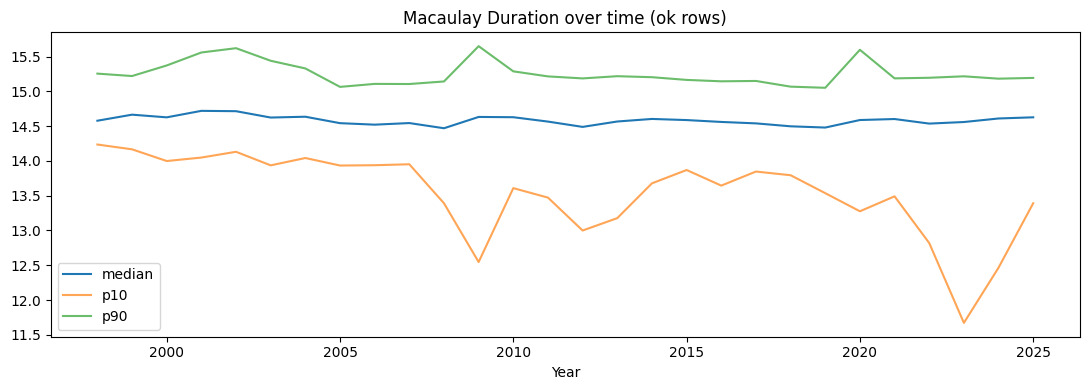

,n,median,mean
trbc_sector,,,
Healthcare,2821,14.792819,14.817443
Technology,4644,14.664904,14.642918
Consumer Non-Cyclicals,2512,14.620660,14.540426
Consumer Cyclicals,5413,14.615778,14.562060
Industrials,6769,14.550758,14.612207
Basic Materials,3307,14.488347,14.265854
Utilities,1709,14.404399,13.960883
Energy,1555,14.394795,14.171060
Real Estate,1108,14.236430,19.024789


In [54]:
ana = result.copy()
if 'asof_date' in ana.columns:
    ana['year'] = pd.to_datetime(ana['asof_date']).dt.year
elif 'date' in ana.columns:
    ana['year'] = pd.to_datetime(ana['date']).dt.year
else:
    ana['year'] = np.nan

ok = ana[ana['status'].eq('ok')].copy()

year_stats = ok.groupby('year')['Duration_DCF_Macaulay'].agg(
    n='count', p10=lambda x: x.quantile(0.10), median='median', p90=lambda x: x.quantile(0.90), mean='mean'
).reset_index()
display(year_stats.head(20))

fig, ax = plt.subplots(1, 1, figsize=(11, 4))
ax.plot(year_stats['year'], year_stats['median'], label='median')
ax.plot(year_stats['year'], year_stats['p10'], label='p10', alpha=0.7)
ax.plot(year_stats['year'], year_stats['p90'], label='p90', alpha=0.7)
ax.set_title('Macaulay Duration over time (ok rows)')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

# Sector merge (if sector exists in source table)
sec_path = DATA_DIR / 'euro500_x_EPS.parquet'
if sec_path.exists() and all(c in ok.columns for c in ['RIC', 'quarter', 'asof_date']):
    sec = pd.read_parquet(sec_path)[['RIC', 'quarter', 'asof_date', 'trbc_sector']].copy()
    sec['asof_date'] = pd.to_datetime(sec['asof_date'])
    ok['asof_date'] = pd.to_datetime(ok['asof_date'])
    ok_sec = ok.merge(sec.drop_duplicates(['RIC', 'quarter', 'asof_date']), on=['RIC', 'quarter', 'asof_date'], how='left')
    sec_stats = ok_sec.groupby('trbc_sector')['Duration_DCF_Macaulay'].agg(n='count', median='median', mean='mean').sort_values('median', ascending=False)
    display(sec_stats.head(15))
else:
    print('Sector stability skipped: required columns or file missing.')


## 9) Analyse: Einfacher Zins-Shock-Test (Long HighD - Short LowD)

Idee: Pro Quartal Duration-Quintile bilden und tägliches Portfolio-Return-Minus (`Q5 - Q1`) auf `dy` (2Y OIS-Änderung) regressieren.
Erwartung bei restriktiven Schocks: negativer Koeffizient.


In [55]:
rets_path = DATA_DIR / 'daily_returns_euro500_in_index.parquet'
ois_path = DATA_DIR / 'rates_2yOIS_daily.parquet'

if not (rets_path.exists() and ois_path.exists()):
    print('Missing required files for shock test.')
else:
    dur_q = result[result['status'].eq('ok')][['RIC', 'quarter', 'Duration_DCF_Macaulay']].copy()
    dur_q = dur_q.dropna().drop_duplicates(['RIC', 'quarter'])

    # quintiles within quarter
    dur_q['q'] = dur_q.groupby('quarter')['Duration_DCF_Macaulay'].transform(
        lambda s: pd.qcut(s.rank(method='first'), 5, labels=[1,2,3,4,5])
    )

    rets = pd.read_parquet(rets_path)[['date', 'quarter', 'RIC', 'ret']].copy()
    rets['date'] = pd.to_datetime(rets['date'])
    rets['ret'] = pd.to_numeric(rets['ret'], errors='coerce')

    px = rets.merge(dur_q[['RIC', 'quarter', 'q']], on=['RIC', 'quarter'], how='inner')
    px = px.dropna(subset=['ret', 'q'])

    q_daily = px.groupby(['date', 'q'])['ret'].mean().reset_index()
    q_wide = q_daily.pivot(index='date', columns='q', values='ret')
    q_wide['LS_5m1'] = q_wide[5] - q_wide[1]

    ois = pd.read_parquet(ois_path).copy()
    ois['date'] = pd.to_datetime(ois['date'])
    ois['dy'] = pd.to_numeric(ois['dy'], errors='coerce')

    reg = q_wide[['LS_5m1']].merge(ois[['date', 'dy']].set_index('date'), left_index=True, right_index=True, how='inner').dropna()

    # OLS via numpy: LS = a + b*dy
    y = reg['LS_5m1'].to_numpy()
    x = reg['dy'].to_numpy()
    X = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]

    yhat = X @ beta
    resid = y - yhat
    n = len(y)
    k = X.shape[1]
    s2 = (resid @ resid) / max(n - k, 1)
    vcov = s2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(vcov))
    tvals = beta / se

    out = pd.DataFrame({
        'coef': beta,
        'std_err': se,
        't_value': tvals
    }, index=['const', 'dy'])

    print('Regression: LS_5m1 ~ const + dy')
    print('n_obs:', n)
    display(out)

    print('Average LS_5m1 daily return:', reg['LS_5m1'].mean())


Regression: LS_5m1 ~ const + dy
n_obs: 4236


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_37177/885919197.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_daily = px.groupby(['date', 'q'])['ret'].mean().reset_index()


,coef,std_err,t_value
const,0.000022,0.000082,0.266308
dy,0.000435,0.002313,0.187859


Average LS_5m1 daily return: 2.180570622428282e-05
